In [1]:
!pip install pami==2026.1.19.1
# pami-2026.1.19.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 8.3 MB/s eta 0:00:00
  Created wheel for JsonForm: filename=JsonForm-0.0.2-py3-none-any.whl size=3311 sha256=1be56a270a1f5ba39ea6ef1b5c7cb03787ef8f2914a6939125f3f1a4ae8d856f
  Stored in directory: /root/.cache/pip/wheels/0b/29/3c/f5b5085becdbee0b282b60cda0028607f67adf8f099316a4a7
  Created wheel for JsonSir: filename=JsonSir-0.0.2-py3-none-any.whl size=4754 sha256=6093ffafe0a4925db97dfa884a

# RFM Clustering

In [2]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Memuat Data

In [3]:
print("Memuat dataset...")
df = pd.read_csv("/kaggle/input/datasets/felixoctavius/online-retail-ii/cleaned.csv")

Memuat dataset...


In [4]:
print("\nPenggunaan RAM tanpa type-casting:\n========================")
df = pd.read_csv("/kaggle/input/datasets/felixoctavius/online-retail-ii/cleaned.csv")
df.info(memory_usage='deep')
print(df.head()) # isi dataset sebelum casting datatype


Penggunaan RAM tanpa type-casting:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790749 entries, 0 to 790748
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      399599 non-null  float64
 1   StockCode    790749 non-null  object 
 2   Description  790749 non-null  object 
 3   Quantity     790749 non-null  int64  
 4   InvoiceDate  790749 non-null  object 
 5   Price        790749 non-null  float64
 6   Customer ID  790749 non-null  int64  
 7   Country      790749 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 220.2 MB
    Invoice StockCode                          Description  Quantity  \
0  489434.0     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434.0    79323P                   PINK CHERRY LIGHTS        12   
2  489434.0    79323W                  WHITE CHERRY LIGHTS        12   
3  489434.0     22041          RECORD FRAME 7" SINGLE SIZE        48   
4

In [5]:
optimized_dtypes = {
    'Quantity': np.int32,      # 32-bit int instead of default 64-bit
    'Price': np.float32,       # 32-bit float instead of default 64-bit
    'Customer ID': 'Int32',    # Pandas Nullable Integer (handles NaNs without using float64)
    'Country': 'category',     # Categorical (only ~40 unique countries)
    'StockCode': 'category'    # Categorical (repetitive product codes)
}

df = pd.read_csv(
    '/kaggle/input/datasets/felixoctavius/online-retail-ii/cleaned.csv', 
    dtype=optimized_dtypes,
    parse_dates=['InvoiceDate']
)

df['Description'] = df['Description'].astype('category')
df['Invoice'] = df['Invoice'].astype('category')

print("\nPenggunaan RAM dengan type-casting:\n========================")
df.info(memory_usage='deep')
print(df.head()) # memastikan data tidak berubah


Penggunaan RAM dengan type-casting:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790749 entries, 0 to 790748
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      399599 non-null  category      
 1   StockCode    790749 non-null  category      
 2   Description  790749 non-null  category      
 3   Quantity     790749 non-null  int32         
 4   InvoiceDate  790749 non-null  datetime64[ns]
 5   Price        790749 non-null  float32       
 6   Customer ID  790749 non-null  Int32         
 7   Country      790749 non-null  category      
dtypes: Int32(1), category(4), datetime64[ns](1), float32(1), int32(1)
memory usage: 22.6 MB
    Invoice StockCode                          Description  Quantity  \
0  489434.0     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434.0    79323P                   PINK CHERRY LIGHTS        12   
2  489434.0    79323W                  WHITE

# 2. Pembersihan Data (Data Cleaning)

In [6]:
import pandas as pd
import numpy as np

def load_and_combine_data(file_path_1, file_path_2):
    print("Loading and combining datasets...")
    df1 = pd.read_csv(file_path_1, encoding='latin1')
    df2 = pd.read_csv(file_path_2, encoding='latin1')
    
    # Combine both years into a single dataframe
    df_combined = pd.concat([df1, df2], ignore_index=True)
    print(f"Combined dataset shape: {df_combined.shape[0]:,} rows.")
    return df_combined

def clean_retail_pipeline(df):
    print("\nStarting basic cleaning...")
    df_clean = df.copy()
    
    # 1. Handle Column Name Variations
    col_customer = 'Customer ID' if 'Customer ID' in df_clean.columns else 'CustomerID'
    col_price = 'Price' if 'Price' in df_clean.columns else 'UnitPrice'
    
    # 2. Drop Exact Duplicates & Missing Values
    df_clean.drop_duplicates(inplace=True)
    df_clean.dropna(subset=[col_customer, 'Description'], inplace=True)
    
    # 3. Format Data Types
    df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
    # Convert Customer ID to string without the .0 float formatting
    df_clean[col_customer] = df_clean[col_customer].astype(int).astype(str)
    # Standardize string formatting for Description
    df_clean['Description'] = df_clean['Description'].astype(str).str.upper().str.strip()
    
    # 4. Filter Anomalies (Returns, Free Items, System Codes)
    df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean[col_price] > 0)]
    
    invalid_codes = ['C2', 'POST', 'D', 'M', 'PADS', 'DOT', 'CRUK', 'BANK CHARGES', 'AMAZONFEE']
    df_clean = df_clean[~df_clean['StockCode'].astype(str).str.upper().isin(invalid_codes)]
    
    print("\nStarting advanced product standardization (Latest Transaction Method)...")
    
    # 5. Master Data Management: Standardize Descriptions to Latest Entry
    # Sort chronologically
    df_clean = df_clean.sort_values(by='InvoiceDate', ascending=True)
    
    # Extract the most recent description for every StockCode
    latest_descriptions = df_clean.drop_duplicates(subset=['StockCode'], keep='last')
    description_mapping = latest_descriptions.set_index('StockCode')['Description'].to_dict()
    
    # Map the latest description back to all historical transactions
    df_clean['Description'] = df_clean['StockCode'].map(description_mapping)
    
    # Final cleanup: sort by date again just to keep the dataframe chronological
    df_clean = df_clean.sort_values(by='InvoiceDate').reset_index(drop=True)
    
    print("\n" + "="*50)
    print("PIPELINE COMPLETE")
    print("="*50)
    print(f"Final cleaned dataset shape: {df_clean.shape[0]:,} rows.")
    
    return df_clean

In [7]:
print("Membersihkan data...")
df = df.dropna(subset=['Customer ID'])

Membersihkan data...


In [8]:
print("Membersihkan StockCode invalid...")
# Pastikan tipe data adalah string dan huruf besar agar seragam
df['StockCode'] = df['StockCode'].astype(str).str.upper()

Membersihkan StockCode invalid...


In [9]:
# Mendefinisikan awalan StockCode yang merepresentasikan data invalid/testing
invalid_prefixes = ('ADJUST', 'TEST')

# Menyaring DataFrame: HANYA SIMPAN baris yang StockCode-nya TIDAK DIAWALI prefix di atas
df = df[~df['StockCode'].str.startswith(invalid_prefixes)]

# Catatan Tambahan: Jika Anda juga ingin membuang kode administratif lain 
# yang umum ada di dataset Online Retail, Anda bisa menambahkan baris ini:
# df = df[~df['StockCode'].isin(['POST', 'D', 'M', 'CRUK', 'DOT'])]

In [10]:
# Mengonversi tipe data
# df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# df['Customer ID'] = df['Customer ID'].astype(int).astype(str)

In [11]:
# Menghapus pesanan yang dibatalkan (Invoice mengandung huruf 'C')
# df = df[~df['Invoice'].str.contains('C', na=False)]
df = df[~df['Invoice'].astype(str).str.contains('C', na=False)]

In [12]:
df.info(memory_usage='deep') # memastikan datatype Invoice tetaplah category

<class 'pandas.core.frame.DataFrame'>
Index: 790704 entries, 0 to 790748
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      399554 non-null  category      
 1   StockCode    790704 non-null  object        
 2   Description  790704 non-null  category      
 3   Quantity     790704 non-null  int32         
 4   InvoiceDate  790704 non-null  datetime64[ns]
 5   Price        790704 non-null  float32       
 6   Customer ID  790704 non-null  Int32         
 7   Country      790704 non-null  category      
dtypes: Int32(1), category(3), datetime64[ns](1), float32(1), int32(1), object(1)
memory usage: 67.6 MB


In [13]:
# Memastikan Kuantitas dan Harga bernilai positif
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [14]:
# Membuat kolom Total Value (Monetary)
df['TotalSum'] = df['Quantity'] * df['Price']

# 3. Kalkulasi RFM

In [15]:
print("Menghitung metrik RFM...")
# Menentukan tanggal acuan (snapshot date) yaitu 1 hari setelah tanggal transaksi terakhir
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

Menghitung metrik RFM...


In [16]:
# Agregasi data pada level Customer
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                    # Frequency
    'TotalSum': 'sum'                                        # Monetary
})

In [17]:
# Mengganti nama kolom agar lebih intuitif
rfm.rename(columns={'InvoiceDate': 'Recency',
                    'Invoice': 'Frequency',
                    'TotalSum': 'Monetary'}, inplace=True)

# 4. Pra-pemrosesan untuk Klasterisasi

In [18]:
# Menangani skewness dengan Log Transformation (menggunakan np.log1p untuk menangani nilai 0)
rfm_log = np.log1p(rfm)

In [19]:
# Standardisasi data agar memiliki mean=0 dan variance=1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

# 5. Klasterisasi menggunakan K-Means

In [20]:
print("Melakukan klasterisasi...")
# Menggunakan k=4 sebagai contoh pembagian segmen
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

Melakukan klasterisasi...


KMeans(n_clusters=4, n_init=10, random_state=42)

In [21]:
# Menyimpan label klaster ke dalam dataframe RFM asli
rfm['Cluster'] = kmeans.labels_

# 6. Analisis dan Karakteristik Profil Pelanggan

In [22]:
# Menghitung nilai rata-rata R, F, M dan jumlah pelanggan per klaster
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

In [23]:
print("\n=== Ringkasan Profil Pelanggan per Klaster ===")
print(cluster_summary)


=== Ringkasan Profil Pelanggan per Klaster ===
        Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         402.1       0.9    317.8  1851
1          26.7      10.8  11748.9  1034
2          36.0       0.4   1103.6  1507
3         236.6       3.7   2039.1  1460


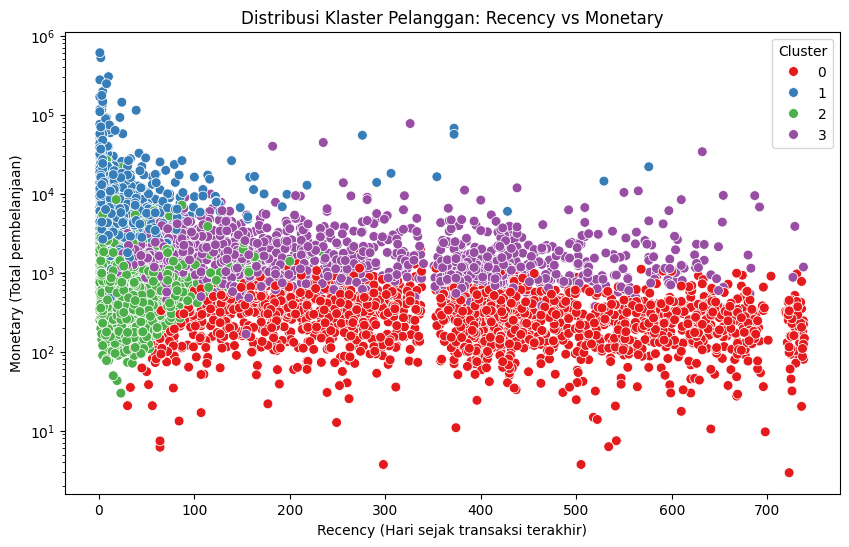

In [24]:
# Visualisasi Distribusi Klaster Recency vs Monetary
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1', s=50)
plt.title('Distribusi Klaster Pelanggan: Recency vs Monetary')
plt.xlabel('Recency (Hari sejak transaksi terakhir)')
plt.ylabel('Monetary (Total pembelanjaan)')
plt.yscale('log') # Log scale untuk visibilitas yang lebih baik
plt.show()

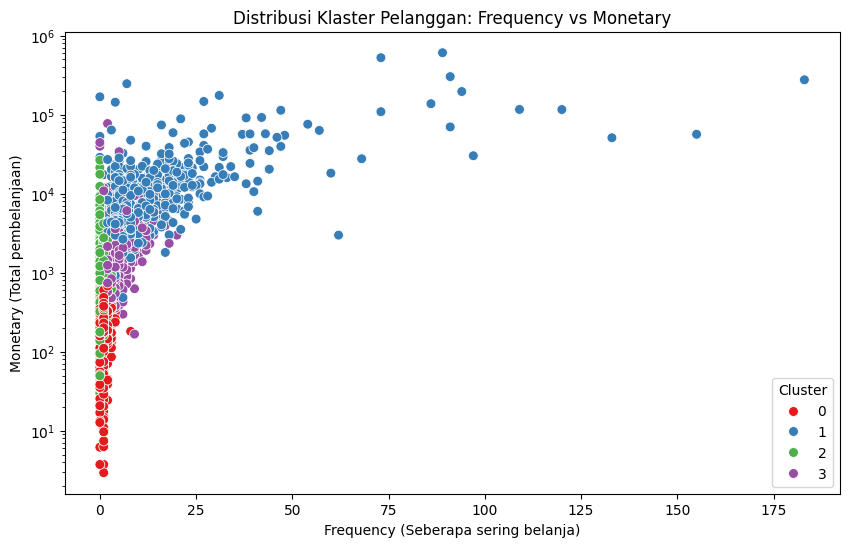

In [25]:
# Visualisasi Distribusi Klaster Frequency vs Monetary
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1', s=50)
plt.title('Distribusi Klaster Pelanggan: Frequency vs Monetary')
plt.xlabel('Frequency (Seberapa sering belanja)')
plt.ylabel('Monetary (Total pembelanjaan)')
plt.yscale('log') # Log scale untuk visibilitas yang lebih baik
plt.show()

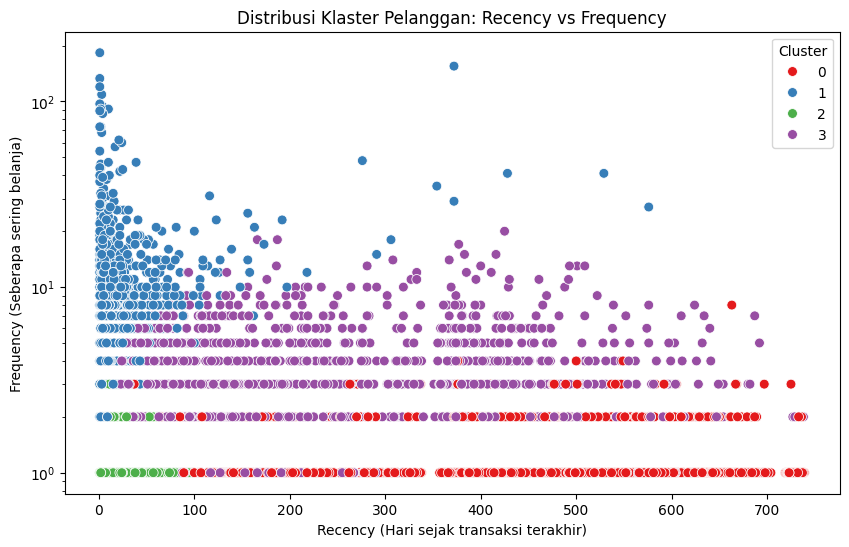

In [26]:
# Visualisasi Distribusi Klaster Recency vs Frequency
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette='Set1', s=50)
plt.title('Distribusi Klaster Pelanggan: Recency vs Frequency')
plt.xlabel('Recency (Hari sejak transaksi terakhir)')
plt.ylabel('Frequency (Seberapa sering belanja)')
plt.yscale('log') # Log scale untuk visibilitas yang lebih baik
plt.show()

# HUIM (PAMI)

In [27]:
import pandas as pd
import numpy as np
import os
# Import algoritma EFIM dari library PAMI
from PAMI.highUtilityPattern.basic import EFIM as efim

# 1. Menggabungkan Data Transaksi dengan Klaster RFM

In [28]:
# Pastikan dataframe 'df' (transaksi asli) dan 'rfm' dari kode sebelumnya sudah tersedia.
# Kita petakan setiap 'Customer ID' di transaksi ke klasternya masing-masing.
df_clustered = df.merge(rfm[['Cluster']], on='Customer ID', how='inner')

In [29]:
df_clustered.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum,Cluster
0,489434.0,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.399998,3
1,489434.0,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.000000,3
2,489434.0,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.000000,3
3,489434.0,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.799995,3
4,489434.0,21232,STRAWBERRY CERAMIC TRINKET POT,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.000000,3


In [30]:
# Verifikasi kesamaan jumlah antara customer dan transaksi per cluster
print(df_clustered.groupby('Cluster', as_index=False)['Customer ID'].count())
print(df_clustered.groupby('Cluster', as_index=False)['StockCode'].count())

   Cluster  Customer ID
0        0        44776
1        1       466968
2        2       114796
3        3       164164
   Cluster  StockCode
0        0      44776
1        1     466968
2        2     114796
3        3     164164


In [31]:
# Kita gunakan 'StockCode' sebagai representasi item.
# Menghapus spasi agar tidak error saat diproses oleh PAMI
df_clustered['StockCode'] = df_clustered['StockCode'].astype(str).str.replace(' ', '')
df_clustered['Utility'] = df_clustered['TotalSum'] # Utility = Revenue

# 2. Fungsi Transformasi Data ke Format PAMI

In [32]:
# Format HUIM PAMI untuk tiap baris transaksi:
# item1\titem2 : total_utility_transaksi : utility_item1\tutility_item2

def prepare_pami_format(data_cluster, cluster_label):
    filename = f"huim_cluster_{cluster_label}.txt"
    print(f"\nMenyiapkan dataset untuk Klaster {cluster_label}...")
    
    # Agregasi item dan utility di dalam satu transaksi (Invoice)
    grouped = data_cluster.groupby('Invoice')
    
    with open(filename, 'w') as f:
        for invoice, group in grouped:
            # Karena bisa ada baris produk yang sama dalam 1 invoice, kita jumlahkan dulu
            item_utils = group.groupby('StockCode')['Utility'].sum().reset_index()
            
            # Abaikan transaksi yang total utility-nya 0 atau negatif
            if item_utils['Utility'].sum() <= 0:
                continue
                
            items = item_utils['StockCode'].tolist()
            utilities = item_utils['Utility'].tolist()
            total_utility = sum(utilities)
            
            # Format ke string
            item_str = '\t'.join(items)
            util_str = '\t'.join(map(lambda x: str(int(x)), utilities)) # PAMI lebih stabil dengan integer utility
            
            # Tulis ke file
            f.write(f"{item_str}:{int(total_utility)}:{util_str}\n")
            
    print(f"File {filename} berhasil dibuat.")
    return filename

# 3. Eksekusi PAMI HUIM pada Masing-Masing Klaster

In [33]:
# Definisikan minimum utility untuk seluruh klaster (ambang batas nilai/revenue). 
# Catatan: Nilai min_util ini bergantung pada skala data Anda. 
# Kita set dinamis misalnya 1% dari total revenue di klaster tersebut.

min_util_threshold = 0.01
for cluster_id in sorted(df_clustered['Cluster'].unique()):
    # Filter data hanya untuk klaster saat ini
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
    
    # Buat file input format PAMI
    input_file = prepare_pami_format(cluster_data, cluster_id)
    
    # Tentukan parameter Minimum Utility (misal: 1% dari total revenue di klaster ini)
    total_cluster_revenue = cluster_data['Utility'].sum()
    min_util = int(total_cluster_revenue * min_util_threshold)
    
    print(f"-> Menjalankan EFIM untuk Klaster {cluster_id} dengan minUtil = {min_util}...")
    
    # Inisiasi Algoritma EFIM dari PAMI
    # iFile: input file, minUtil: batas minimum utilitas, sep: pemisah item (default tab)
    obj = efim.EFIM(iFile=input_file, minUtil=min_util, sep='\t')
    
    # Mulai mining
    obj.mine()
    
    # Mendapatkan hasil
    patterns = obj.getPatterns()
    output_file = f"output_patterns_cluster_{cluster_id}.txt"
    obj.save(output_file)
    
    print(f"-> Ditemukan {len(patterns)} pola High-Utility Itemsets (HUIs).")
    print(f"-> Memori (USS) yang digunakan: {obj.getMemoryUSS() / (1048576)} MB. Waktu eksekusi: {obj.getRuntime()} detik.")
    
    # Menampilkan 5 pola dengan utility tertinggi sebagai sampel
    if len(patterns) > 0:
        # Parsing pola untuk diurutkan berdasarkan nilai utility
        parsed_patterns = []
        for p, u in patterns.items():
            # Mengubah tuple/string menjadi format yang mudah diolah
            parsed_patterns.append({'Itemset': p, 'Total_Utility': u})
            
        df_patterns = pd.DataFrame(parsed_patterns)
        df_patterns = df_patterns.sort_values(by='Total_Utility', ascending=False).head(5)
        
        print(f"   [Top 5 High-Utility Itemsets - Klaster {cluster_id}]:")
        for idx, row in df_patterns.iterrows():
            print(f"   - Items: {row['Itemset']} | Revenue Tercipta: £{row['Total_Utility']}")
    else:
        print("   - Tidak ada pola yang melampaui minUtil. Coba turunkan threshold minUtil.")
    
    # Opsional: Hapus file text temporary untuk menghemat penyimpanan
    # os.remove(input_file)
    # print("-" * 50)


Menyiapkan dataset untuk Klaster 0...


/tmp/ipykernel_16/378446182.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data_cluster.groupby('Invoice')


File huim_cluster_0.txt berhasil dibuat.
-> Menjalankan EFIM untuk Klaster 0 dengan minUtil = 5882...
High Utility patterns were generated successfully using EFIM algorithm
-> Ditemukan 0 pola High-Utility Itemsets (HUIs).
-> Memori (USS) yang digunakan: 508.26953125 MB. Waktu eksekusi: 0.05599474906921387 detik.
   - Tidak ada pola yang melampaui minUtil. Coba turunkan threshold minUtil.

Menyiapkan dataset untuk Klaster 1...


/tmp/ipykernel_16/378446182.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data_cluster.groupby('Invoice')


File huim_cluster_1.txt berhasil dibuat.
-> Menjalankan EFIM untuk Klaster 1 dengan minUtil = 121483...
High Utility patterns were generated successfully using EFIM algorithm
-> Ditemukan 0 pola High-Utility Itemsets (HUIs).
-> Memori (USS) yang digunakan: 508.9609375 MB. Waktu eksekusi: 0.6069045066833496 detik.
   - Tidak ada pola yang melampaui minUtil. Coba turunkan threshold minUtil.

Menyiapkan dataset untuk Klaster 2...


/tmp/ipykernel_16/378446182.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data_cluster.groupby('Invoice')


File huim_cluster_2.txt berhasil dibuat.
-> Menjalankan EFIM untuk Klaster 2 dengan minUtil = 16632...
High Utility patterns were generated successfully using EFIM algorithm
-> Ditemukan 0 pola High-Utility Itemsets (HUIs).
-> Memori (USS) yang digunakan: 508.96484375 MB. Waktu eksekusi: 0.01873779296875 detik.
   - Tidak ada pola yang melampaui minUtil. Coba turunkan threshold minUtil.

Menyiapkan dataset untuk Klaster 3...


/tmp/ipykernel_16/378446182.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data_cluster.groupby('Invoice')


File huim_cluster_3.txt berhasil dibuat.
-> Menjalankan EFIM untuk Klaster 3 dengan minUtil = 29770...
High Utility patterns were generated successfully using EFIM algorithm
-> Ditemukan 1 pola High-Utility Itemsets (HUIs).
-> Memori (USS) yang digunakan: 508.96484375 MB. Waktu eksekusi: 0.26137757301330566 detik.
   [Top 5 High-Utility Itemsets - Klaster 3]:
   - Items: 85123A | Revenue Tercipta: £33505
